# Men's Rankings

Get ratings of each team in a given year. This file needs to be ran for every relevant year (starting in 2012). 

### Data Setup

In [1]:
import pandas as pd

season = 2024

df = pd.read_parquet(fr'..\data\unprocessed\mens_sports_reference\sports_reference_{season}.parquet')

df

,Date,Team,Location,Opponent,Result,Team Score,Opponent Score,Team FG,Team FGA,Team FG%,...,Opponent TOV,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo
0,2023-11-06,Abilene Christian,-1,Oklahoma State,1,64.0,59.0,26.0,57.0,0.456,...,12.0,16.0,0,0,5.0,1.253292,70.32,0.910125,0.839022,70.320000
1,2023-11-10,Abilene Christian,-1,NC State,-1,64.0,84.0,20.0,57.0,0.351,...,7.0,20.0,0,0,-20.0,1.500000,66.72,0.959233,1.258993,66.720000
2,2023-11-14,Abilene Christian,1,Prairie View,-1,74.0,79.0,23.0,60.0,0.383,...,14.0,23.0,0,0,-5.0,1.253292,71.86,1.029780,1.099360,71.860000
3,2023-11-17,Abilene Christian,0,San Jose State,1,77.0,71.0,25.0,59.0,0.424,...,6.0,18.0,0,0,6.0,1.285760,65.86,1.169147,1.078044,65.860000
4,2023-11-19,Abilene Christian,0,Fordham,1,59.0,45.0,22.0,55.0,0.400,...,19.0,16.0,0,0,14.0,1.448039,65.86,0.895840,0.683268,65.860000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,2024-02-17,Youngstown State,-1,Cleveland State,-1,73.0,81.0,25.0,58.0,0.431,...,9.0,22.0,0,0,-8.0,1.338710,72.46,1.007452,1.117858,72.460000
11234,2024-02-23,Youngstown State,-1,Milwaukee,1,84.0,80.0,32.0,78.0,0.410,...,14.0,23.0,1,1,4.0,1.214668,79.80,1.052632,1.002506,70.933333
11235,2024-02-25,Youngstown State,-1,Green Bay,1,71.0,59.0,26.0,55.0,0.473,...,10.0,15.0,0,0,12.0,1.417062,62.22,1.141112,0.948248,62.220000
11236,2024-02-28,Youngstown State,1,Detroit Mercy,1,69.0,55.0,26.0,61.0,0.426,...,9.0,14.0,0,0,14.0,1.448039,67.68,1.019504,0.812648,67.680000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11238 entries, 0 to 11237
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11238 non-null  datetime64[ns]
 1   Team                         11238 non-null  object        
 2   Location                     11238 non-null  int8          
 3   Opponent                     11238 non-null  object        
 4   Result                       11238 non-null  int8          
 5   Team Score                   11238 non-null  float64       
 6   Opponent Score               11238 non-null  float64       
 7   Team FG                      11238 non-null  float64       
 8   Team FGA                     11238 non-null  float64       
 9   Team FG%                     11238 non-null  float64       
 10  Team 3P                      11238 non-null  float64       
 11  Team 3PA                     11238 non-nu

Create recency bias

In [3]:
# games at the beginning of the season should be about 0.8, games at the end will be 1.2

df['Recency Bias'] = 0.996018**(df['Date'].max() - df['Date']).dt.days + 0.2

df

,Date,Team,Location,Opponent,Result,Team Score,Opponent Score,Team FG,Team FGA,Team FG%,...,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias
0,2023-11-06,Abilene Christian,-1,Oklahoma State,1,64.0,59.0,26.0,57.0,0.456,...,16.0,0,0,5.0,1.253292,70.32,0.910125,0.839022,70.320000,0.785872
1,2023-11-10,Abilene Christian,-1,NC State,-1,64.0,84.0,20.0,57.0,0.351,...,20.0,0,0,-20.0,1.500000,66.72,0.959233,1.258993,66.720000,0.795298
2,2023-11-14,Abilene Christian,1,Prairie View,-1,74.0,79.0,23.0,60.0,0.383,...,23.0,0,0,-5.0,1.253292,71.86,1.029780,1.099360,71.860000,0.804875
3,2023-11-17,Abilene Christian,0,San Jose State,1,77.0,71.0,25.0,59.0,0.424,...,18.0,0,0,6.0,1.285760,65.86,1.169147,1.078044,65.860000,0.812159
4,2023-11-19,Abilene Christian,0,Fordham,1,59.0,45.0,22.0,55.0,0.400,...,16.0,0,0,14.0,1.448039,65.86,0.895840,0.683268,65.860000,0.817063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,2024-02-17,Youngstown State,-1,Cleveland State,-1,73.0,81.0,25.0,58.0,0.431,...,22.0,0,0,-8.0,1.338710,72.46,1.007452,1.117858,72.460000,1.083655
11234,2024-02-23,Youngstown State,-1,Milwaukee,1,84.0,80.0,32.0,78.0,0.410,...,23.0,1,1,4.0,1.214668,79.80,1.052632,1.002506,70.933333,1.105065
11235,2024-02-25,Youngstown State,-1,Green Bay,1,71.0,59.0,26.0,55.0,0.473,...,15.0,0,0,12.0,1.417062,62.22,1.141112,0.948248,62.220000,1.112316
11236,2024-02-28,Youngstown State,1,Detroit Mercy,1,69.0,55.0,26.0,61.0,0.426,...,14.0,0,0,14.0,1.448039,67.68,1.019504,0.812648,67.680000,1.123302


### Model Building

##### Team Ratings

In [4]:
X = (
    pd.get_dummies(df['Team']).astype('int8') -
    pd.get_dummies(df['Opponent']).astype('int8')
)

X['Home Field Advantage'] = df['Location'].copy()

X

,Abilene Christian,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,...,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
11234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
11235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
11236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [5]:
from sklearn.model_selection import GroupKFold
import numpy as np

def get_gkf_data(X, y, w, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # sample weights
        w_train = w[train_index]

        data.append((X_train, X_test, y_train, y_test, w_train))

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Result'].to_numpy(), df['Adjusted Score Differential'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [6]:
def rescale_weights(arr, minimum, maximum):
    """
    Rescale the weights array to match desired weights.
    Assumes the data is already transformed where a 1 point win is 1.00, a blowout is 1.50, and a tie is 0.50.
    Ties will be weighted as half the minimum.
    """

    arr_scaled = ((arr - 1.00) / 0.50) * (maximum - minimum) + minimum
    arr_scaled[arr == 0.50] = minimum / 2
    return arr_scaled

In [7]:
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
import warnings
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    C = trial.suggest_float('C', 0.1, 10, log=True)
    mod = LogisticRegression(penalty='l2', C=C, fit_intercept=False)
    minimum = trial.suggest_float('minimum', 0.1, 1.0, step=0.1)
    maximum = trial.suggest_float('maximum', 1.0, 8.0, step=0.5)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test, w_train in cv_data:
        y_actuals.append(y_test)

        weights = rescale_weights(w_train, minimum, maximum)

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')  # prevent convergence warnings
            mod.fit(X_train, y_train, sample_weight=weights)

        y_preds.append(mod.predict_proba(X_test)[:, 1])

    return log_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'C': 0.21060782526441282, 'minimum': 0.8, 'maximum': 4.0}

In [8]:
minimum = study.best_params['minimum']
maximum = study.best_params['maximum']

weight = rescale_weights(df['Adjusted Score Differential'], minimum, maximum)*df['Recency Bias']

mod = LogisticRegression(penalty='l2', C=study.best_params['C'], fit_intercept=False)

mod.fit(X, df['Result'], sample_weight=weight)

df_ratings = pd.DataFrame(
    {
        'Team': X.columns,
        'BT Rating': mod.coef_[0]
    }
).sort_values(by=['BT Rating'], ascending=False, ignore_index=True)

df_ratings

,Team,BT Rating
0,Purdue,2.748541
1,Connecticut,2.742999
2,Houston,2.601162
3,North Carolina,2.298939
4,Auburn,2.213047
...,...,...
358,Virginia Military Institute,-2.423878
359,IUPUI,-2.453905
360,Coppin State,-2.519868
361,Detroit Mercy,-2.655124


Make stronger adjustments based on strength of schedule

In [9]:
team_to_bt_rating = dict(zip(df_ratings['Team'], df_ratings['BT Rating']))

df['Opponent BT Rating'] = df['Opponent'].map(team_to_bt_rating)

df

,Date,Team,Location,Opponent,Result,Team Score,Opponent Score,Team FG,Team FGA,Team FG%,...,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias,Opponent BT Rating
0,2023-11-06,Abilene Christian,-1,Oklahoma State,1,64.0,59.0,26.0,57.0,0.456,...,0,0,5.0,1.253292,70.32,0.910125,0.839022,70.320000,0.785872,-0.213076
1,2023-11-10,Abilene Christian,-1,NC State,-1,64.0,84.0,20.0,57.0,0.351,...,0,0,-20.0,1.500000,66.72,0.959233,1.258993,66.720000,0.795298,0.979924
2,2023-11-14,Abilene Christian,1,Prairie View,-1,74.0,79.0,23.0,60.0,0.383,...,0,0,-5.0,1.253292,71.86,1.029780,1.099360,71.860000,0.804875,-1.464951
3,2023-11-17,Abilene Christian,0,San Jose State,1,77.0,71.0,25.0,59.0,0.424,...,0,0,6.0,1.285760,65.86,1.169147,1.078044,65.860000,0.812159,-0.948519
4,2023-11-19,Abilene Christian,0,Fordham,1,59.0,45.0,22.0,55.0,0.400,...,0,0,14.0,1.448039,65.86,0.895840,0.683268,65.860000,0.817063,-0.539019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,2024-02-17,Youngstown State,-1,Cleveland State,-1,73.0,81.0,25.0,58.0,0.431,...,0,0,-8.0,1.338710,72.46,1.007452,1.117858,72.460000,1.083655,0.114941
11234,2024-02-23,Youngstown State,-1,Milwaukee,1,84.0,80.0,32.0,78.0,0.410,...,1,1,4.0,1.214668,79.80,1.052632,1.002506,70.933333,1.105065,-0.114702
11235,2024-02-25,Youngstown State,-1,Green Bay,1,71.0,59.0,26.0,55.0,0.473,...,0,0,12.0,1.417062,62.22,1.141112,0.948248,62.220000,1.112316,-0.201808
11236,2024-02-28,Youngstown State,1,Detroit Mercy,1,69.0,55.0,26.0,61.0,0.426,...,0,0,14.0,1.448039,67.68,1.019504,0.812648,67.680000,1.123302,-2.655124


In [10]:
# make sure results are 1/-1 for win/loss for this chunk to work properly

def rescale_ratings(arr, minimum, maximum):
    """
    Rescale the ratings array to match desired weights.
    """
    return ((arr - arr.min()) / (arr.max() - arr.min())) * (maximum - minimum) + minimum

def get_sos(result: int, quantiles: list) -> pd.DataFrame:
    """
    Get the strength of teams beat/lost to at different quantiles.
    For example, best win or worst lost.
    """
    data = (
        df.loc[df['Result'] == result, :]
        .groupby(['Team'])['Opponent BT Rating']
        .quantile(quantiles)
        .reset_index()
        .pivot(index='Team', columns='level_1')
        .reset_index()
    )
    data.index.name = None
    if result > 0:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Win' for v in data.columns]
    else:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Loss' for v in data.columns]

    return data

df_advanced_ratings = pd.merge(
    get_sos(-1, [0.00, 0.10, 0.20]),
    get_sos(1, [1.00, 0.90, 0.80]),
    how='outer',
    on=['Team'],
)

df_advanced_ratings.insert(1, 'BT Rating', df_advanced_ratings['Team'].map(team_to_bt_rating))

# in case teams did not win or did not lose a game, just fill it with the team's own rating
for c in df_advanced_ratings.columns[1:]:
    df_advanced_ratings.loc[df_advanced_ratings[c].isna(), c] = df_advanced_ratings['BT Rating']

df_advanced_ratings.insert(
    1,
    'Rating',
    rescale_ratings(
        np.average(df_advanced_ratings.iloc[:, 1:], weights=[0.4] + [0.1]*6, axis=1),
        df_ratings['BT Rating'].min(),
        df_ratings['BT Rating'].max(),
    ),
)

df_advanced_ratings.sort_values(by=['Rating'], ascending=False, inplace=True, ignore_index=True)

df_advanced_ratings

,Team,Rating,BT Rating,0.0 Loss,0.1 Loss,0.2 Loss,0.8 Win,0.9 Win,1.0 Win
0,Purdue,2.748541,2.748541,1.077919,1.123595,1.169271,1.654437,1.972100,2.079577
1,Connecticut,2.630943,2.742999,0.924092,1.018292,1.112492,1.119265,1.734881,2.298939
2,Houston,2.563600,2.601162,1.074132,1.170420,1.266707,1.266208,1.412080,2.075457
3,Tennessee,2.469288,2.079577,1.277655,1.359860,1.404462,1.595186,1.786485,2.213047
4,Auburn,2.462638,2.213047,1.358861,1.394655,1.447812,1.390346,1.635935,1.824811
...,...,...,...,...,...,...,...,...,...
357,Virginia Military Institute,-2.001527,-2.423878,-1.464309,-1.001629,-0.780523,-0.993664,-0.993664,-0.993664
358,Stonehill,-2.056838,-2.354311,-2.155112,-1.392128,-1.050512,-1.007057,-0.775698,-0.544340
359,Coppin State,-2.101066,-2.519868,-1.748255,-1.296164,-1.014702,-0.946438,-0.846211,-0.745984
360,Mississippi Valley State,-2.626128,-2.846540,-2.364397,-1.350824,-1.159690,-1.464951,-1.464951,-1.464951


In [11]:
df_ratings_display = df_advanced_ratings[['Team', 'Rating']].copy()
df_ratings_display.index += 1

df_ratings_display['Strength'] = (np.exp(df_ratings_display['Rating'])/(1 + np.exp(df_ratings_display['Rating'])))*100

df_ratings_display

,Team,Rating,Strength
1,Purdue,2.748541,93.983087
2,Connecticut,2.630943,93.282667
3,Houston,2.563600,92.848185
4,Tennessee,2.469288,92.196058
5,Auburn,2.462638,92.148073
...,...,...,...
358,Virginia Military Institute,-2.001527,11.904265
359,Stonehill,-2.056838,11.336323
360,Coppin State,-2.101066,10.899324
361,Mississippi Valley State,-2.626128,6.747569


##### Adjusted Offense/Defense Ratings

In [12]:
X_offense = pd.get_dummies(
    df['Team']
).astype('int8')

X_offense.columns += ' Offense'

X_defense = -pd.get_dummies(
    df['Opponent']
).astype('int8')

X_defense.columns += ' Defense'

X = pd.concat([X_offense, X_defense], axis=1)

X['Home Field Advantage'] = df['Location'].copy()

X

,Abilene Christian Offense,Air Force Offense,Akron Offense,Alabama Offense,Alabama A&M Offense,Alabama State Offense,Albany (NY) Offense,Alcorn State Offense,American Offense,Appalachian State Offense,...,William & Mary Defense,Winthrop Defense,Wisconsin Defense,Wofford Defense,Wright State Defense,Wyoming Defense,Xavier Defense,Yale Defense,Youngstown State Defense,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
11234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
11235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
11236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [13]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Team PPP'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 2.273515185111001}

In [15]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Team PPP'], sample_weight=df['Recency Bias'])

df_ppp = pd.DataFrame(
    {
        'Team': X.columns,
        'Rating': mod.coef_
    }
).sort_values(by=['Rating'], ascending=False, ignore_index=True)

df_ppp

,Team,Rating
0,Houston Defense,0.194915
1,Connecticut Offense,0.187300
2,Alabama Offense,0.182485
3,Purdue Offense,0.178864
4,Iowa State Defense,0.175839
...,...,...
720,Siena Offense,-0.148878
721,Maryland-Eastern Shore Offense,-0.149338
722,Virginia Military Institute Offense,-0.160349
723,Coppin State Offense,-0.195731


In [16]:
df_ppp.loc[df_ppp['Team'].str.contains('Home Field'), :]

,Team,Rating
253,Home Field Advantage,0.023972


In [17]:
df_ppp_offense = df_ppp.loc[df_ppp['Team'].str.contains(' Offense$', regex=True), :].reset_index(drop=True)

df_ppp_offense['Team'] = df_ppp_offense['Team'].str.replace(' Offense$', '', regex=True)

df_ppp_offense['Rating'] += mod.intercept_

df_ppp_offense.head(25)

,Team,Rating
0,Connecticut,1.235397
1,Alabama,1.230582
2,Purdue,1.226961
3,Illinois,1.217742
4,Baylor,1.213263
5,Gonzaga,1.197173
6,Duke,1.196210
7,Arizona,1.194376
8,Kentucky,1.194159
9,Auburn,1.193665


In [18]:
df_ppp_defense = df_ppp.loc[df_ppp['Team'].str.contains(' Defense$', regex=True), :].reset_index(drop=True)

df_ppp_defense['Team'] = df_ppp_defense['Team'].str.replace(' Defense$', '', regex=True)

df_ppp_defense['Rating'] = mod.intercept_ - df_ppp_defense['Rating']

df_ppp_defense.head(25)

,Team,Rating
0,Houston,0.853182
1,Iowa State,0.872259
2,Tennessee,0.910907
3,Saint Mary's (CA),0.919677
4,Auburn,0.922657
5,Rutgers,0.927242
6,North Carolina,0.928838
7,Arizona,0.929254
8,Michigan State,0.933329
9,San Diego State,0.934456


In [19]:
df_ppp_all = pd.merge(
    df_ppp_offense.rename(columns={'Rating': 'Adjusted Offense'}),
    df_ppp_defense.rename(columns={'Rating': 'Adjusted Defense'}),
    how='inner',
    on=['Team']
)

df_ppp_all.head(25)

,Team,Adjusted Offense,Adjusted Defense
0,Connecticut,1.235397,0.941866
1,Alabama,1.230582,1.009651
2,Purdue,1.226961,0.956426
3,Illinois,1.217742,1.003750
4,Baylor,1.213263,0.996168
5,Gonzaga,1.197173,0.987155
6,Duke,1.196210,0.964546
7,Arizona,1.194376,0.929254
8,Kentucky,1.194159,1.015710
9,Auburn,1.193665,0.922657


##### Adjusted Pace Ratings

In [20]:
X = (
    pd.get_dummies(df['Team']).astype('int8') +
    pd.get_dummies(df['Opponent']).astype('int8')
)

X

,Abilene Christian,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,...,Wichita State,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11233,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [21]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Tempo'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [22]:
def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 5.610476538926824}

In [23]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Tempo'], sample_weight=df['Recency Bias'])

df_tempo = pd.DataFrame(
    {
        'Team': X.columns,
        'Adjusted Tempo': mod.coef_
    }
).sort_values(by=['Adjusted Tempo'], ascending=False, ignore_index=True)

df_tempo

,Team,Adjusted Tempo
0,Western Kentucky,7.047083
1,Virginia Military Institute,6.468355
2,Bryant,6.208262
3,Kennesaw State,6.127109
4,Maryland-Baltimore County,5.669940
...,...,...
357,Charlotte,-4.844799
358,North Texas,-5.342724
359,Air Force,-5.582826
360,Wagner,-5.831542


In [24]:
df_tempo['Adjusted Tempo'] += mod.intercept_

df_tempo

,Team,Adjusted Tempo
0,Western Kentucky,75.730148
1,Virginia Military Institute,75.151420
2,Bryant,74.891326
3,Kennesaw State,74.810174
4,Maryland-Baltimore County,74.353005
...,...,...
357,Charlotte,63.838266
358,North Texas,63.340341
359,Air Force,63.100239
360,Wagner,62.851523


### Visualizations

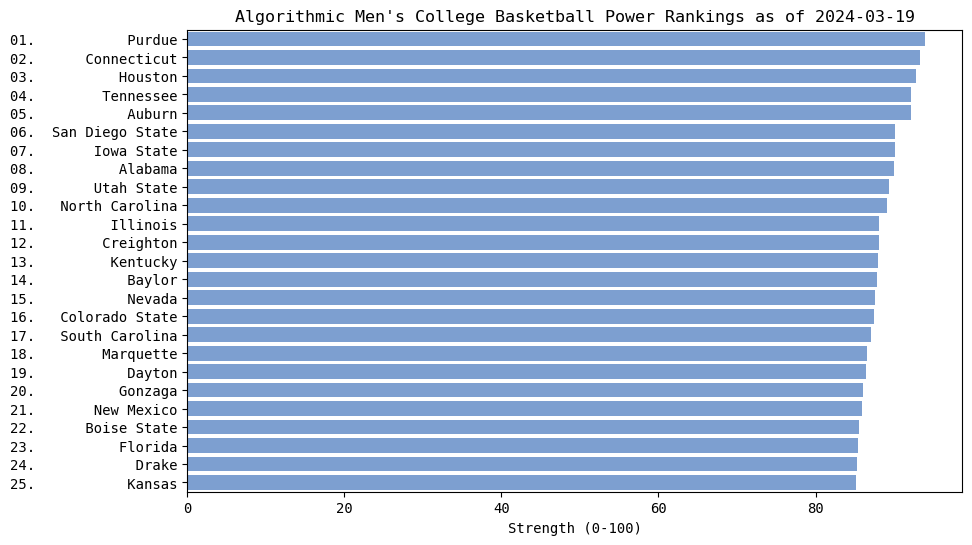

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'monospace'  # so spacing is consistent for y axis

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ratings_display.head(25)['Strength'],
    y=(
        df_ratings_display.head(25).index.map(lambda x: str(x).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ratings_display.head(25)['Team'].str.pad(max(df_ratings_display.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#6f9cde',
    dodge=False
)

plt.xlabel('Strength (0-100)')
plt.ylabel(None)
plt.title(f"Algorithmic Men's College Basketball Power Rankings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

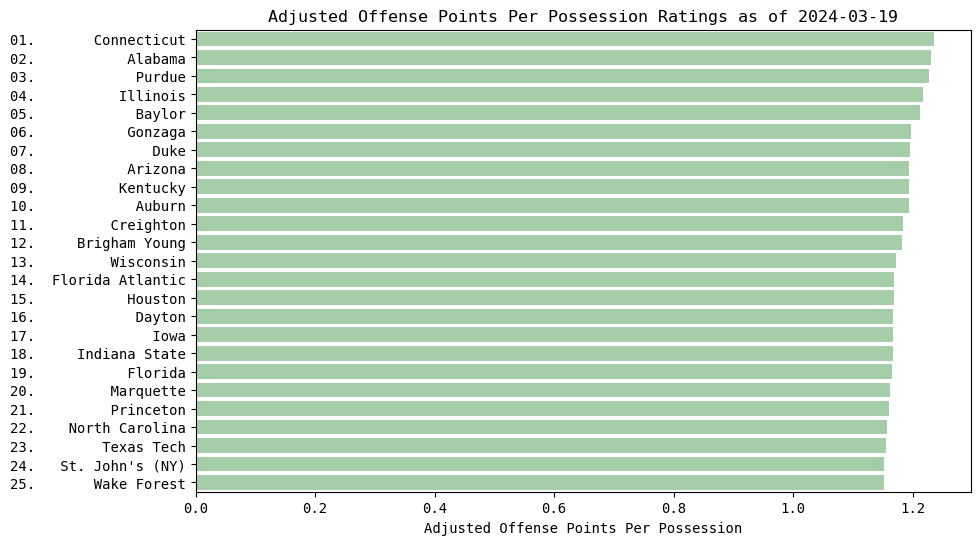

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_offense.head(25)['Rating'],
    y=(
        df_ppp_offense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_offense.head(25)['Team'].str.pad(max(df_ppp_offense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#9fd4a3',
    dodge=False
)

plt.xlabel('Adjusted Offense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Offense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

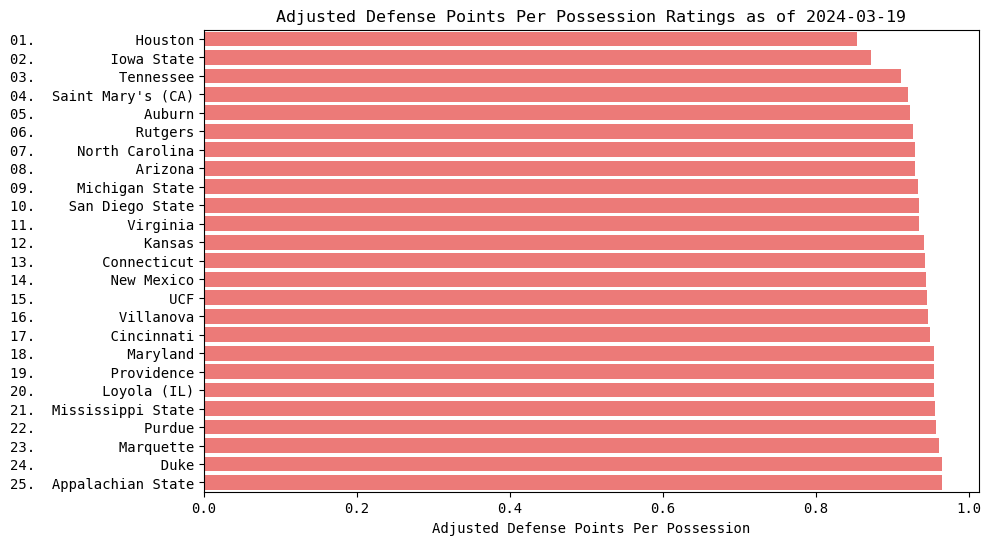

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_defense.head(25)['Rating'],
    y=(
        df_ppp_defense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_defense.head(25)['Team'].str.pad(max(df_ppp_defense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ff6865',
    dodge=False
)

plt.xlabel('Adjusted Defense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Defense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

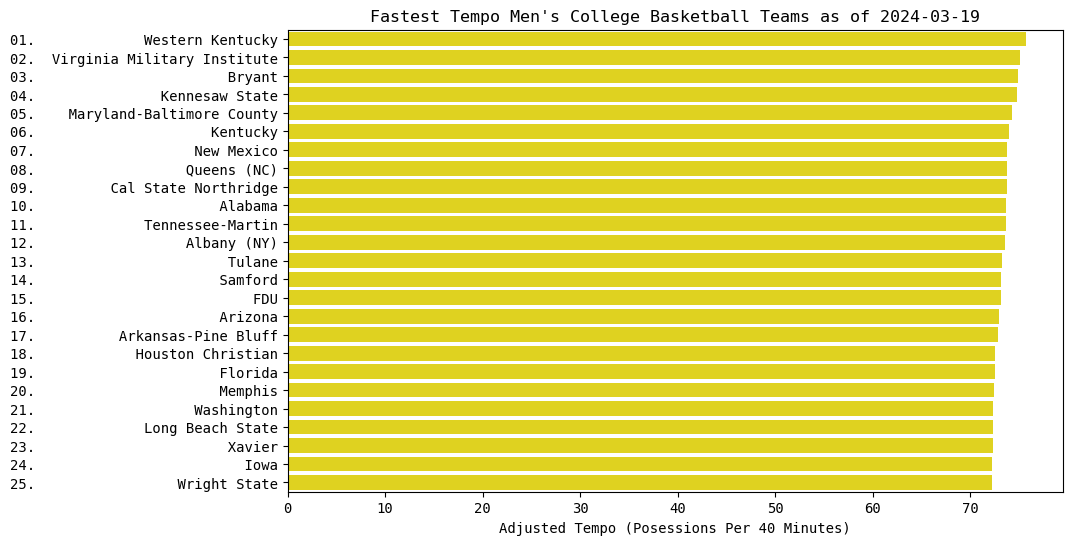

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_tempo.head(25)['Adjusted Tempo'],
    y=(
        df_tempo.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_tempo.head(25)['Team'].str.pad(max(df_tempo.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ffee00',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Fastest Tempo Men's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

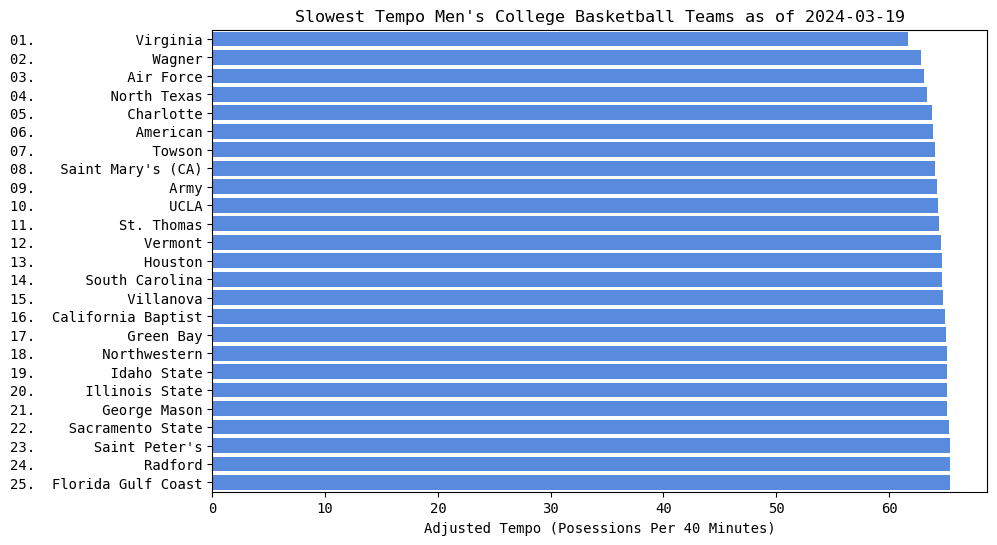

In [29]:
plt.figure(figsize=(10, 6))

df_slow = df_tempo.tail(25).iloc[::-1].reset_index(drop=True)

ax = sns.barplot(
    x=df_slow['Adjusted Tempo'],
    y=(
        df_slow.index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_slow['Team'].str.pad(max(df_slow['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#4285f4',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Slowest Tempo Men's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

In [30]:
import plotly.express as px

fig = px.scatter(
    df_ppp_all,
    x='Adjusted Offense',
    y='Adjusted Defense',
    hover_data='Team',
    title=f'Adjusted Points Per Possession Ratings as of {df["Date"].max().strftime("%Y-%m-%d")}',
    width=1_000, height=600,
)

fig.update_layout(
    font_family='monospace',
    hovermode='closest',
    yaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis_range=(df_ppp_all['Adjusted Offense'].min()-0.01, df_ppp_all['Adjusted Offense'].max()+0.01),
    yaxis_range=(df_ppp_all['Adjusted Defense'].max()+0.01, df_ppp_all['Adjusted Defense'].min()-0.01),
)

fig.update_traces(marker=dict(size=12))

fig.add_vline(
    x=df_ppp_all['Adjusted Offense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

fig.add_hline(
    y=df_ppp_all['Adjusted Defense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

# sloped gridlines
minimum = min(df_ppp_all['Adjusted Offense'].min(), df_ppp_all['Adjusted Defense'].min())-0.01
maximum = max(df_ppp_all['Adjusted Offense'].max(), df_ppp_all['Adjusted Defense'].max())+0.01

for offset in np.linspace(0, maximum-minimum, 6):
    fig.add_scatter(
        x=(minimum+offset, maximum+offset),
        y=(minimum, maximum),
        mode='lines',
        line_color='grey',
        opacity=0.25,
        showlegend=False,
        hoverinfo='skip'
    )

    if offset:
        fig.add_scatter(
            x=(minimum-offset, maximum-offset),
            y=(minimum, maximum),
            mode='lines',
            line_color='grey',
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        )

fig.show()

### Miscellaneous

##### Save Rankings

In [31]:
df_sheet = pd.merge(
    df_ratings_display, df_ppp_all,
    how='left',
    on=['Team']
)

df_sheet = pd.merge(
    df_sheet, df_tempo,
    how='left',
    on=['Team']
)

df_sheet.insert(
    df_sheet.columns.get_loc('Adjusted Offense'),
    'Efficiency Margin',
    df_sheet['Adjusted Offense'] - df_sheet['Adjusted Defense']
)

df_sheet

,Team,Rating,Strength,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo
0,Purdue,2.748541,93.983087,0.270535,1.226961,0.956426,68.431771
1,Connecticut,2.630943,93.282667,0.293531,1.235397,0.941866,66.215369
2,Houston,2.563600,92.848185,0.316181,1.169363,0.853182,64.703058
3,Tennessee,2.469288,92.196058,0.239553,1.150460,0.910907,69.831425
4,Auburn,2.462638,92.148073,0.271007,1.193665,0.922657,70.519650
...,...,...,...,...,...,...,...
357,Virginia Military Institute,-2.001527,11.904265,-0.230590,0.887748,1.118338,75.151420
358,Stonehill,-2.056838,11.336323,-0.211164,0.917356,1.128521,68.998300
359,Coppin State,-2.101066,10.899324,-0.248831,0.852367,1.101197,67.573169
360,Mississippi Valley State,-2.626128,6.747569,-0.323167,0.851673,1.174840,65.665662


In [32]:
df_sheet.to_parquet(f'../data/preprocessed/mens_my_rankings/my_rankings_{season}.parquet', index=False)

'Done'

'Done'